### Loading Necessary library

In [1]:
# #installing packages
# !pip install category-encoders
# !pip install -U scikit-learn
#!pip install scipy

In [2]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import category_encoders as ce
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import math 
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string
from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
import datetime
from collections import Counter
from IPython.display import clear_output
from sklearn import datasets, linear_model
from sklearn.model_selection import LeaveOneOut
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import mutual_info_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score, explained_variance_score, make_scorer
from sklearn.model_selection import LeaveOneOut, cross_val_score,KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
%matplotlib inline

ModuleNotFoundError: No module named 'category_encoders'

### Loading the Data

In [4]:
df=pd.read_excel("Real estate valuation data set.xlsx")
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5


Data information

The inputs are as follows <br>
X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.) <br>
X2=the house age (unit: year) <br>
X3=the distance to the nearest MRT station (unit: meter) <br>
X4=the number of convenience stores in the living circle on foot (integer) <br>
X5=the geographic coordinate, latitude. (unit: degree) <br>
X6=the geographic coordinate, longitude. (unit: degree) <br>

**Referece**

[1] UCI Machine Learning Repository, "Real estate valuation data set," UCI Machine Learning Repository, May 5, 2021. [Online]. Available: https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set. [Accessed: Jul. 23, 2024].


In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
# for i in range(len(df)):
#     frac,whole=math.modf(df['X1 transaction date'][i])
#     sd12=datetime.datetime.strptime("12/31/11", "%m/%d/%y")
#     sd13=datetime.datetime.strptime("12/31/12", "%m/%d/%y")
#     if whole==12:
#         df.loc[i,'Transaction_Date']=(sd12+datetime.timedelta(days=frac*366)).date()
#     else:
#         df.loc[i,'Transaction_Date']=(sd13+datetime.timedelta(days=frac*365)).date()

### Finding the shape and information of the table. 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


There is no null value as seen from here. 

In [7]:
df.shape
print ("There are {} number of rows and {} number of columns in the dataset".format (df.shape[0],df.shape[1]))

There are 414 number of rows and 8 number of columns in the dataset


In [8]:
#Deleting non relevant columns
del df['No'] 


In [9]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
df.loc[df.duplicated(keep=False), :]

Number of duplicate rows = 0


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


In [10]:
collist=df.columns

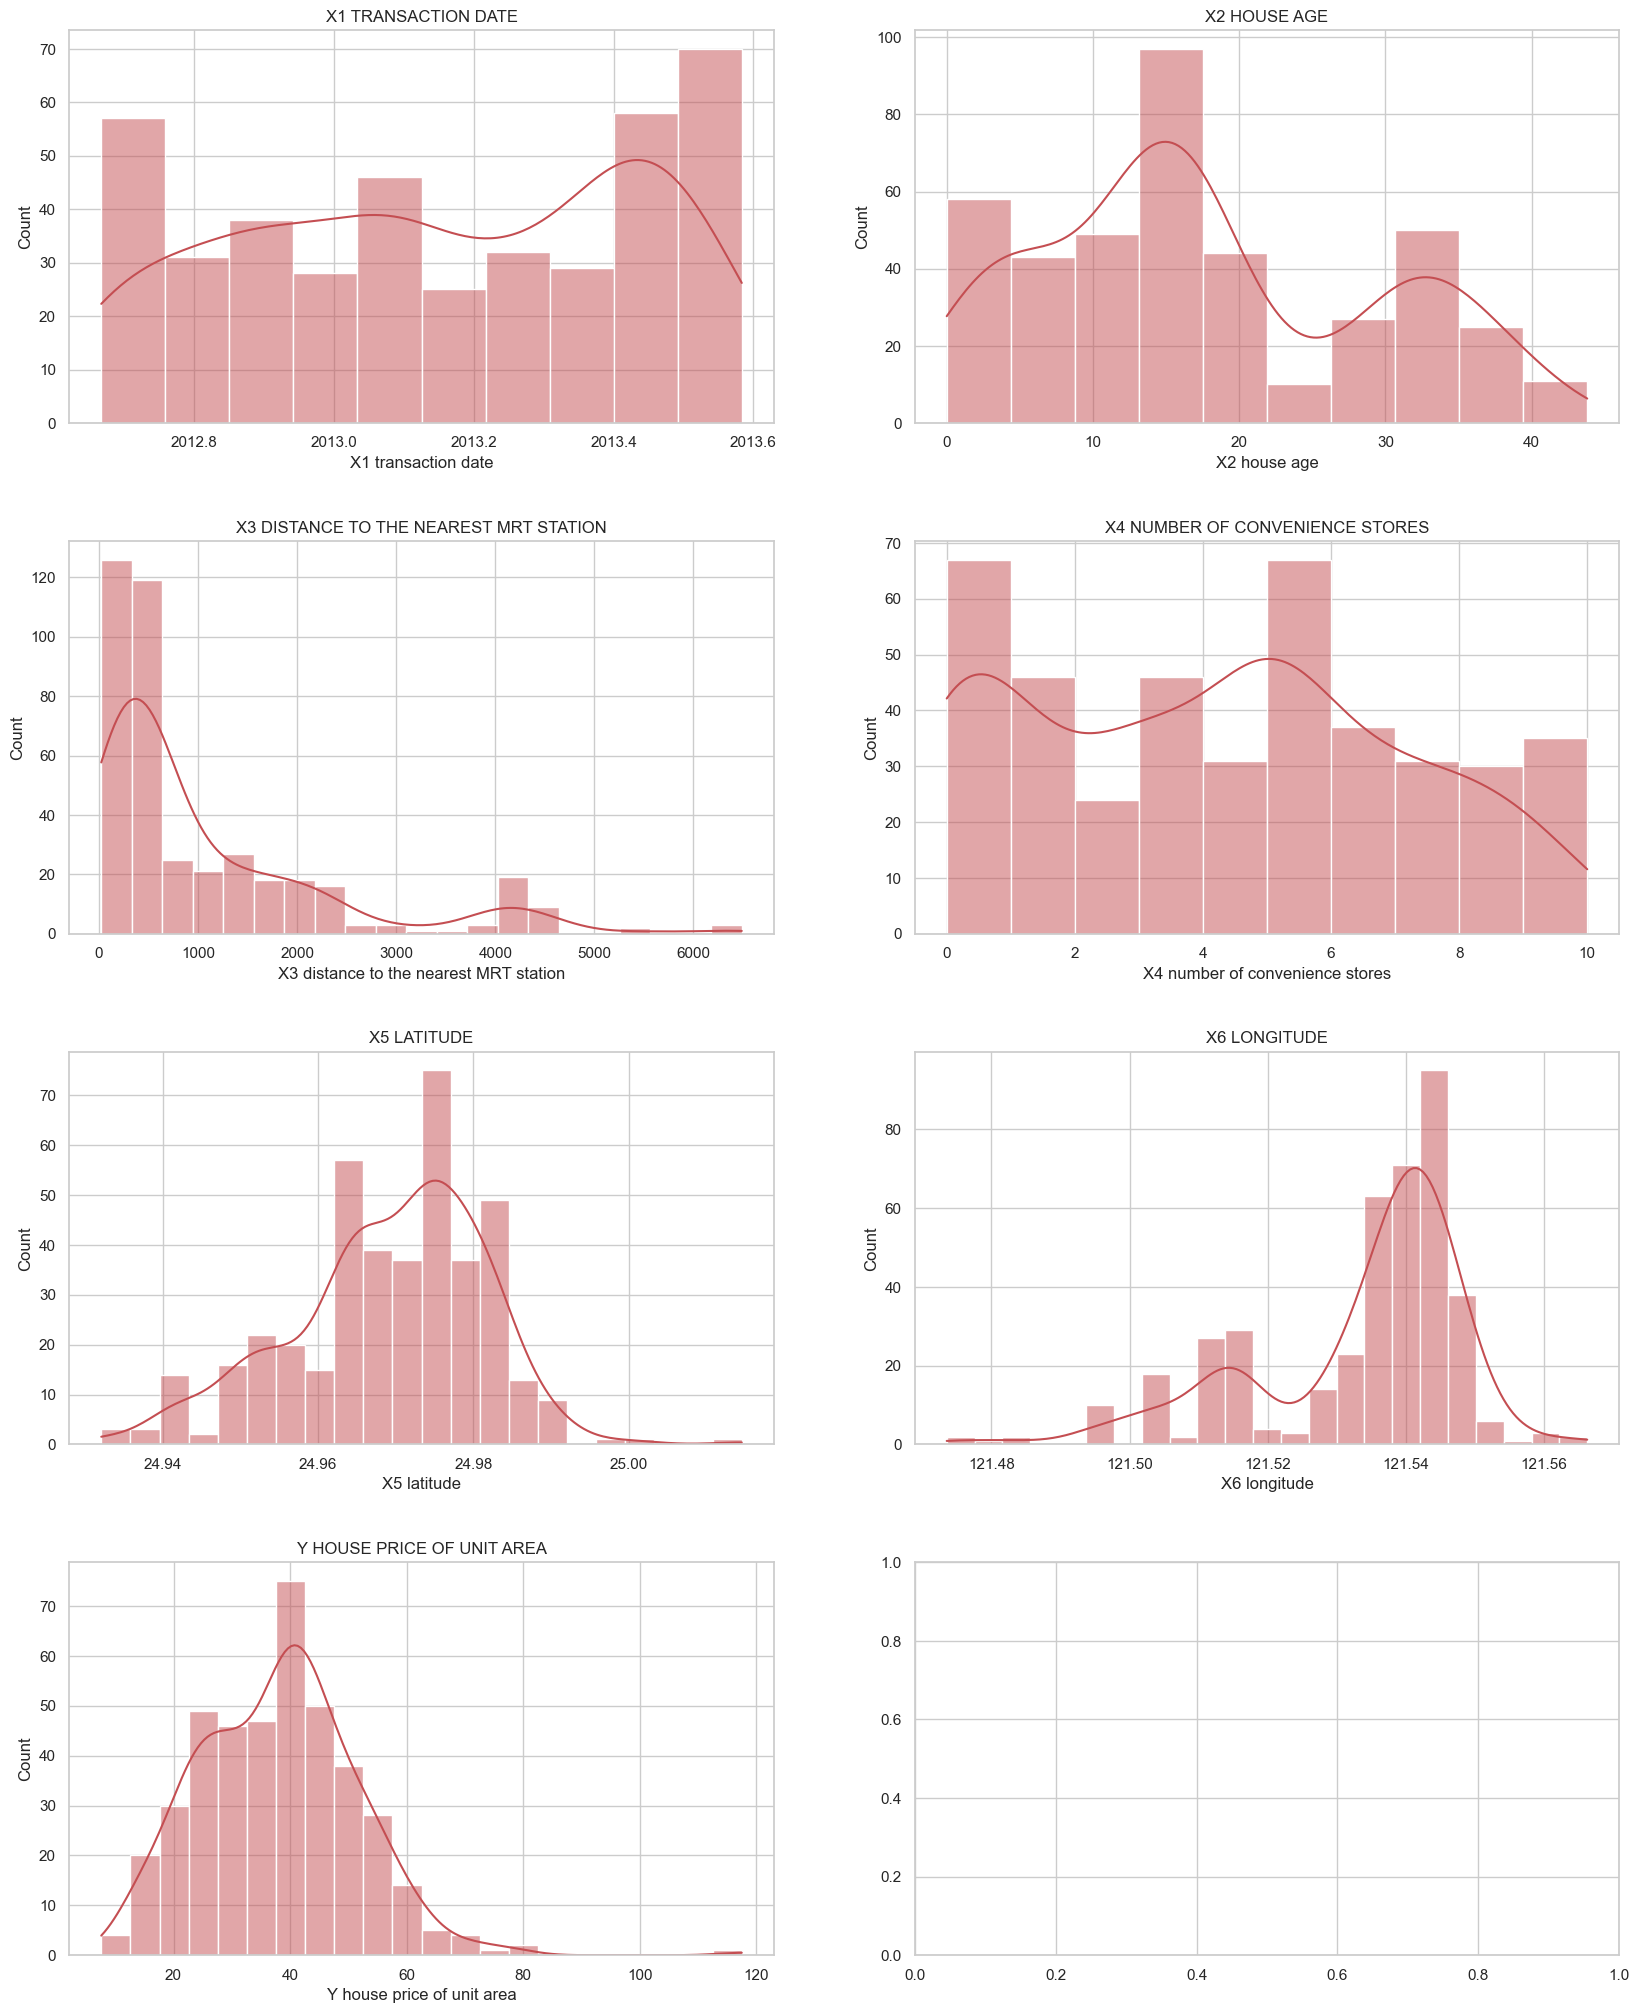

In [11]:
fig,axes = plt.subplots(4,2,figsize=(20,25))
plt.subplots_adjust(hspace=0.3,wspace=0.2)
for i,j in zip(df.columns,axes.flatten()):
    sns.histplot(x=i,data = df,ax=j,kde=True,color='r')
    j.set_title(i.upper())

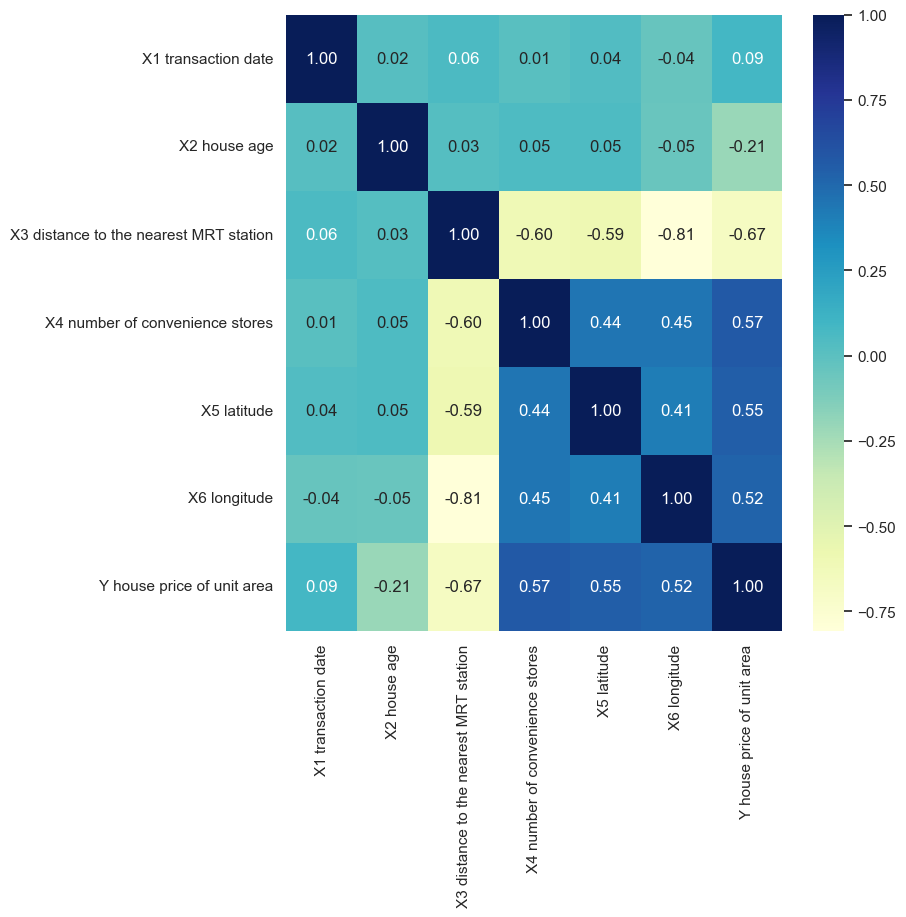

In [12]:
fig = plt.subplots(figsize=(8, 8))
sns.heatmap(df.corr(), annot=True,fmt='.2f',cmap="YlGnBu");
plt.show()

The transaction date Has very small (0.09) correlation and hence it will not be a best member to explain the target variable house price. hence we can drop the same. 

In [13]:
# del df['X1 transaction date']

### Outlier Handling

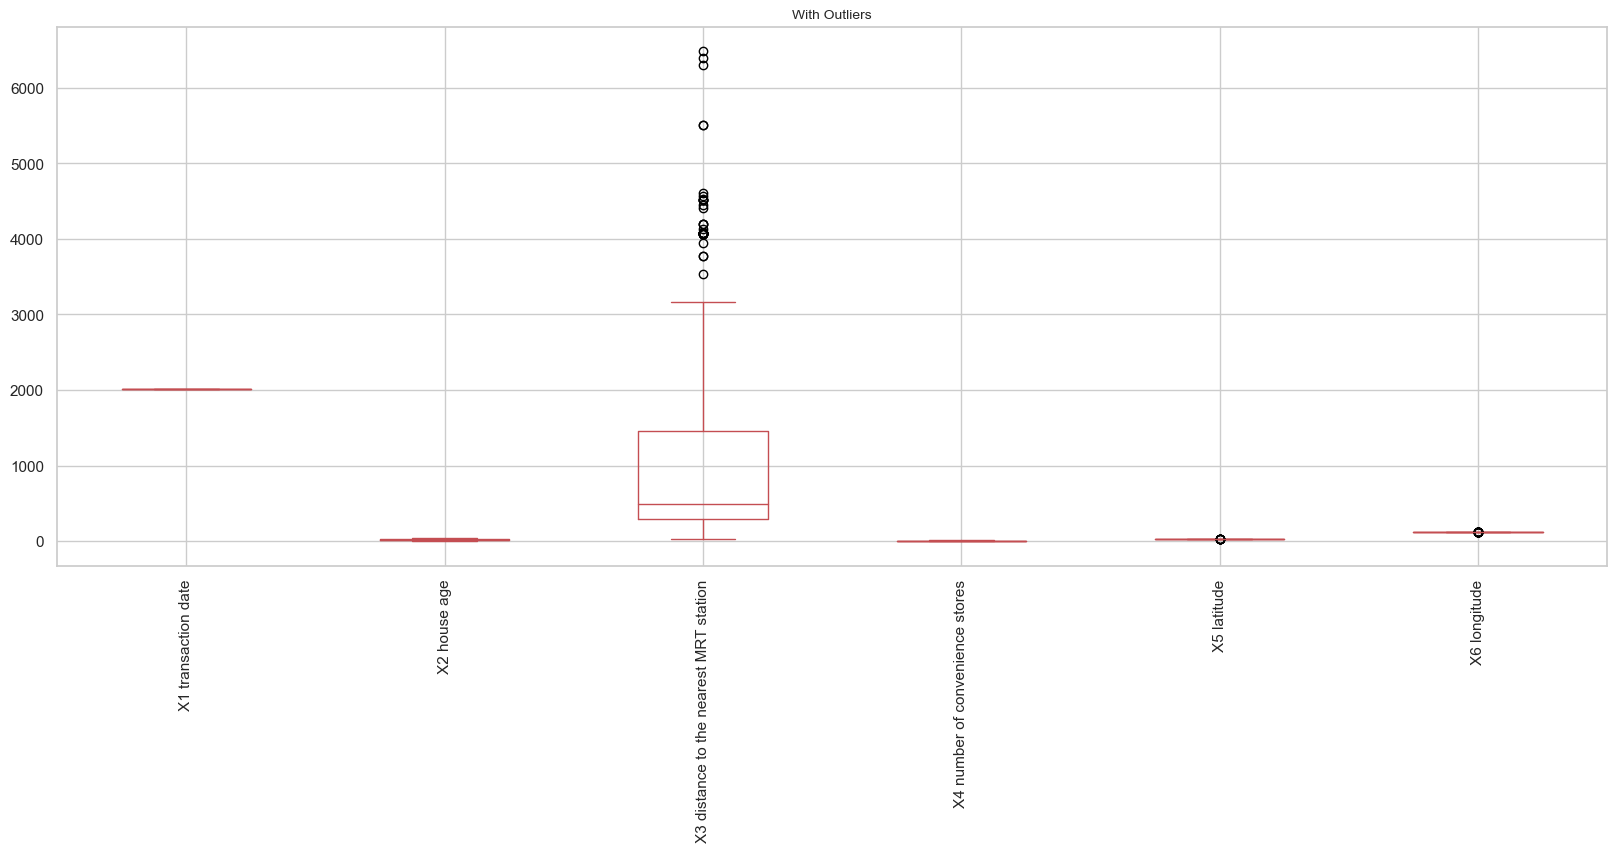

In [14]:
df[df.columns.difference(['Y house price of unit area'])].boxplot(figsize=(20,7),color='r',)
plt.xticks(rotation=90)
plt.title('With Outliers',fontsize=10)
plt.show()

##### Finding Outlier

In [15]:
def olf(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  ol=((df[column] < LB) | (df[column] > UB)).sum() 
  return print("Number of outliers in the column- {} is : {}".format(column,ol))

In [16]:
oltlist=df.columns.difference(['Y house price of unit area'])

In [17]:
for i in oltlist:
    olf(i)

Number of outliers in the column- X1 transaction date is : 0
Number of outliers in the column- X2 house age is : 0
Number of outliers in the column- X3 distance to the nearest MRT station is : 37
Number of outliers in the column- X4 number of convenience stores is : 0
Number of outliers in the column- X5 latitude is : 8
Number of outliers in the column- X6 longitude is : 35


##### Treating the Outliers

In [18]:
def olt(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  df[column]=np.where(df[column]>UB, UB, df[column])
  df[column]=np.where(df[column]<LB, LB, df[column])

In [19]:
for i in df.columns:
    olt(i)

In [20]:
# Rechecking the outliers count. 
for i in df.columns:
    olf(i)

Number of outliers in the column- X1 transaction date is : 0
Number of outliers in the column- X2 house age is : 0
Number of outliers in the column- X3 distance to the nearest MRT station is : 0
Number of outliers in the column- X4 number of convenience stores is : 0
Number of outliers in the column- X5 latitude is : 0
Number of outliers in the column- X6 longitude is : 0
Number of outliers in the column- Y house price of unit area is : 0


### Splitting the Dataset

In [21]:
X = df.drop('Y house price of unit area',axis=1)
y = np.array(df['Y house price of unit area']).reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 , random_state=1)

### Scaling of variables.

Scaling the data after the split here. Because if we scale the data before split, the scaling might affect the test dataset in a way it is treating along with the test dataset. In a real life scenario we might have a different data with entirely distribution and extrimities coming in as the test data. If we do the scaling after splitting, the test data now will have its own scaling distribution 

This prevent data leakage. 

In [22]:
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
scaler_y = StandardScaler()
# from sklearn.preprocessing import MinMaxScaler
# scaler_x = MinMaxScaler()
# scaler_y = MinMaxScaler()


In [23]:
X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = (scaler_y.fit_transform(y_train)).flatten().tolist()

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = (scaler_y.transform(y_test)).flatten().tolist()

### Model Building

In [24]:
regr = LinearRegression()
regr.fit(X_train_scaled, y_train_scaled )
LR_y_pred_scaled = regr.predict(X_test_scaled) 

In [25]:
LRtrs=round(regr.score(X_train_scaled,y_train_scaled),2)
LRtes=round(regr.score(X_test_scaled,y_test_scaled),2)

print(f"with Linear Regression Regularization the train score is {LRtrs}, and the test score is {LRtes} however lets check if all the variables are considered")

with Linear Regression Regularization the train score is 0.64, and the test score is 0.67 however lets check if all the variables are considered


In [26]:
LR_r2=round(r2_score(y_test_scaled, LR_y_pred_scaled),2)

In [27]:
feature_coefficients_LR = pd.DataFrame({
    'feature': X.columns,
    'coefficient_LR': np.abs(regr.coef_)
}).sort_values(by='coefficient_LR', ascending=False)
feature_coefficients_LR

,feature,coefficient_LR
2,X3 distance to the nearest MRT station,0.485131
4,X5 latitude,0.225620
1,X2 house age,0.220661
3,X4 number of convenience stores,0.188937
0,X1 transaction date,0.101295
5,X6 longitude,0.004938


### Evaluation Metrics

####  Mean Absolute Error (MAE)

Definition: The average of the absolute differences between the predicted and actual values. <br>
Interpretation: Lower values indicate better model performance.<br>
<center>MAE = (1/n) * Σ|yi - ŷi| </center> 


[2] Scikit-learn, "sklearn.metrics.mean_absolute_error," Scikit-learn, Jul. 14, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html. [Accessed: Jul. 28, 2024].



In [28]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_scaled, LR_y_pred_scaled)
print(f'Mean Absolute Error (MAE): {mae}')


Mean Absolute Error (MAE): 0.438125724165976


#### Mean Squared Error (MSE)

Definition: The average of the squared differences between the predicted and actual values. <br>
Interpretation: Lower values indicate better model performance.<br>
<center> MSE = (1/n) * Σ(yi - ŷi)^2 </center>


[2] Scikit-learn, "sklearn.metrics.mean_squared_error," Scikit-learn, Jul. 14, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html. [Accessed: Jul. 28, 2024].


In [29]:

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test_scaled, LR_y_pred_scaled)
print(f'Mean Squared Error (MSE): {mse}')


Mean Squared Error (MSE): 0.3777869046480894


#### Root Mean Squared Error (RMSE)

Definition: The average of the absolute differences between the predicted and actual values. <br>
Interpretation: Lower values indicate better model performance.<br>
<center>RMSE = sqrt((1/n) * Σ(yi - ŷi)^2)  </center>


[2] Scikit-learn, "sklearn.metrics.mean_squared_error," Scikit-learn, Jul. 14, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html. [Accessed: Jul. 28, 2024].


In [30]:

# Root Mean Squared Error (RMSE)
Model_rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {Model_rmse}')


Root Mean Squared Error (RMSE): 0.614643721718598


#### R-squared (R²)

Definition: The proportion of the variance in the dependent variable that is predictable from the independent variables.<br>
Interpretation: Values range from 0 to 1, with higher values indicating better model performance.<br>
<center>R² = 1 - Σ(yi - ŷi)^2 / Σ(yi - ȳ)^2  </center>


[3] Scikit-learn, "sklearn.metrics.r2_score," Scikit-learn, Jul. 28, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html. [Accessed: Jul. 14, 2024].


In [31]:

# R-squared (R²)
r2 = r2_score(y_test_scaled, LR_y_pred_scaled)
print(f'R-squared (R²): {r2}')


R-squared (R²): 0.6718866656488122


#### Adjusted R-squared

Definition: A modified version of R-squared that adjusts for the number of predictors in the model. <br>
Interpretation: Higher values indicate better model performance, accounting for model complexity.<br>
<center>Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)] </center>


[4] Wikipedia, "Coefficient of determination - Adjusted R²," Wikipedia, The Free Encyclopedia, Jul. 14, 2024. [Online]. Available: https://en.wikipedia.org/wiki/Coefficient_of_determination#Adjusted_R2. [Accessed: Jul. 14, 2024].


In [32]:

# Adjusted R-squared
n = len(y_test)
p = 1  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'Adjusted R-squared: {adjusted_r2}')


Adjusted R-squared: 0.6692190775646563


#### Mean Absolute Percentage Error (MAPE) Not for Evaluation

Definition: The mean of the absolute percentage errors. <br>
Interpretation: Lower values indicate better model performance.<br>
<center>MAPE = (1/n) * Σ| (yi - ŷi) / yi | * 100</center>



[4] Wikipedia, "Mean absolute percentage error," Wikipedia, The Free Encyclopedia, Jul. 28, 2024. [Online]. Available: https://en.wikipedia.org/wiki/Mean_absolute_percentage_error. [Accessed: Jul. 14, 2024].


In [33]:

# # Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test_scaled, LR_y_pred_scaled) / y_test_scaled)) * 100
# print(f'Mean Absolute Percentage Error (MAPE): {mape}')


#### Mean Bias Deviation (MBD) Not for Evaluation

Definition: The average of the biases (differences between predicted and actual values). <br>
Interpretation: Values close to 0 indicate less bias in the model.<br>
<center>MBD = (1/n) * Σ(yi - ŷi) </center>


https://en.wikipedia.org/wiki/Bias_of_an_estimator



In [34]:

# # Mean Bias Deviation (MBD)
# mbd = np.mean(y_test_scaled, LR_y_pred_scaled)
# print(f'Mean Bias Deviation (MBD): {mbd}')


#### Explained Variance Score Not for Evaluation

Definition: Measures the proportion of the variance explained by the model. <br>
Interpretation: Higher values indicate better model performance.<br>
<center> Explained Variance = 1 - Var(y - ŷ) / Var(y) </center>



https://scikit-learn.org/stable/modules/generated/sklearn.metrics.explained_variance_score.html


In [35]:

# Explained Variance Score
explained_variance = explained_variance_score(y_test_scaled, LR_y_pred_scaled)
print(f'Explained Variance Score: {explained_variance}')

Explained Variance Score: 0.6739580903277058


### Metrics Calculation UDF

In [36]:
mae=[]
mse=[]
rmse=[]
r2=[]
adjusted_r2=[]
mape=[]
mbd=[]
explained_variance=[]
mod=[]

In [37]:
def metrics(m,y_true,y_pred):
    mod.append(m)
    mae.append(mean_absolute_error(y_true, y_pred))
    # print(f'Mean Absolute Error (MAE): {mae}')

    # Mean Squared Error (MSE)
    mse.append(mean_squared_error(y_true, y_pred))
    # print(f'Mean Squared Error (MSE): {mse}')

    # Root Mean Squared Error (RMSE)
    rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    # print(f'Root Mean Squared Error (RMSE): {rmse}')

    # R-squared (R²)
    r2.append(r2_score(y_true, y_pred))
    # print(f'R-squared (R²): {r2}')

    # Adjusted R-squared
    n = len(y_true)
    p = 1  # Number of predictors
    adjusted_r2.append(1 - (1 - r2_score(y_true, y_pred)) * (n - 1) / (n - p - 1))
    # print(f'Adjusted R-squared: {adjusted_r2}')

    # Mean Absolute Percentage Error (MAPE)
    mape.append(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    # print(f'Mean Absolute Percentage Error (MAPE): {mape}')

    # Mean Bias Deviation (MBD)
    mbd.append(np.mean(y_true - y_pred))
    # print(f'Mean Bias Deviation (MBD): {mbd}')

    # Explained Variance Score
    explained_variance.append(explained_variance_score(y_true, y_pred))
    # print(f'Explained Variance Score: {explained_variance}')


In [38]:
metrics(m="LR",y_true=y_test_scaled,y_pred=LR_y_pred_scaled)
metric_Df=pd.DataFrame({'Model':mod,"Mean Absolute Error (MAE)":mae,
"Mean Squared Error (MSE)":mse,
"Root Mean Squared Error (RMSE)":rmse,
"R-squared (R²)":r2,
"Adjusted R-squared":adjusted_r2,
"Mean Absolute Percentage Error (MAPE)":mape,
"Mean Bias Deviation (MBD)":mbd,
"Explained Variance Score":explained_variance})
metric_Df.drop_duplicates().sort_values(by='R-squared (R²)',ascending=False)

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared (R²),Adjusted R-squared,Mean Absolute Percentage Error (MAPE),Mean Bias Deviation (MBD),Explained Variance Score
0,LR,0.438126,0.377787,0.614644,0.671887,0.669219,132.623754,0.048837,0.673958


### Cross Validation LOOCV and 5Fold CV

#### Leave One Out Cross Validation

[5] Analytics Vidhya, "Improve model performance using cross-validation (in Python & R)," Analytics Vidhya, May 15, 2018. [Online]. Available: https://www.analyticsvidhya.com/blog/2018/05/improve-model-performance-cross-validation-in-python-r/#:~:text=%5B%2Dsample%2C%20%5D-,Leave%20one%20out%20cross%20validation%20(LOOCV),its%20own%20advantages%20and%20disadvantages. [Accessed: Jul. 28, 2024].


[6] R. Khalid, "Cross-validation: Calculating R² and accuracy scores after LOOCV," Codeburst, Feb. 4, 2019. [Online]. Available: https://codeburst.io/cross-validation-calculating-r%C2%B2-and-accuracy-scores-after-loocv-5bd1015a50ec. [Accessed: Jul. 28, 2024].


[7] Scikit-learn, "scikit-learn regression metrics," GitHub, Jul. 28, 2024. [Online]. Available: https://github.com/scikit-learn/scikit-learn/blob/a24c8b46/sklearn/metrics/regression.py#L540. [Accessed: Jul. 14, 2024].


In [39]:
X = df.drop('Y house price of unit area',axis=1)
y = df['Y house price of unit area']


loo = LeaveOneOut()
loo.get_n_splits(X)

LOO_y_predl=[]
LOO_y_testl=[]

rmse_avg=[]
for i, j in loo.split(X):
    LOO_X_train, LOO_X_test= X.iloc[i], X.iloc[j]
    LOO_y_train, LOO_y_test= y.iloc[i], y.iloc[j]

    regr.fit(LOO_X_train, LOO_y_train)
    LOO_y_pred=regr.predict(LOO_X_test)
    LOO_mse=(mean_squared_error(LOO_y_test, LOO_y_pred))
    Loo_rmse=np.sqrt(LOO_mse)
    rmse_avg.append(Loo_rmse)
    LOO_y_testl.append(LOO_y_test)
    LOO_y_predl.append(LOO_y_pred)
LOO_y_predl=np.array(LOO_y_predl)
LOO_y_testl=np.array(LOO_y_testl)
LOOCV_AVG_RMSE=np.average(rmse_avg)
# print(f'Average Root Mean Squared Error with LOOCV is: {round(LOOCV_AVG_RMSE,2)}')
# print(f'R2 with LOOCV is: {round(r2_score(LOO_y_testl,LOO_y_predl),2)}')
# metrics(LOO_y_testl,LOO_y_predl)

In [40]:
LOOCV_R2=round(r2_score(LOO_y_testl, LOO_y_predl),2)

In [41]:
metrics(m="LOOCV",y_true=LOO_y_testl,y_pred=LOO_y_predl)
metric_Df=pd.DataFrame({'Model':mod,"Mean Absolute Error (MAE)":mae,
"Mean Squared Error (MSE)":mse,
"Root Mean Squared Error (RMSE)":rmse,
"R-squared (R²)":r2,
"Adjusted R-squared":adjusted_r2,
"Mean Absolute Percentage Error (MAPE)":mape,
"Mean Bias Deviation (MBD)":mbd,
"Explained Variance Score":explained_variance})
metric_Df.drop_duplicates().sort_values(by='R-squared (R²)',ascending=False)

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared (R²),Adjusted R-squared,Mean Absolute Percentage Error (MAPE),Mean Bias Deviation (MBD),Explained Variance Score
0,LR,0.438126,0.377787,0.614644,0.671887,0.669219,132.623754,0.048837,0.673958
1,LOOCV,5.687721,61.883015,7.866576,0.639188,0.638312,17.298649,0.012541,0.639188


Pro's and Cons of LOOCV

**Advantage:**
> + LOOCV has more resilient to Bias. It can tackle biased data as well. <br>
> + It uses maximum of data to predict a point compared to other CV. <br>
> + Since we are considering every index and rest as training there is no randomness on the data while splitting. <br>
> + Since every point is considered to testing the evaluation is considered as complete. <br>

**Disadvantage:**
> - computationally very expensive as it has to do n number of testing where n is the number of line items. <br>
> - Potential that it can overfit the data as the model is trained for almost all the data. <br>
> - Not suitable for a large dataset only for a small dataset. <br>


#### 5 Fold Cross Validation

In [42]:
# Initialize five-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Perform cross-validation and calculate scores
mse_scores = cross_val_score(regr, X, y, cv=kf, scoring=make_scorer(mean_squared_error))
rmse_scores=[]
for i in mse_scores:
    rmse_scores.append(np.sqrt(i))
# Calculate the average MSE
KFold_average_rmse = np.mean(rmse_scores)
print(f'Average Root Mean Squared Error with 5 Fold Cross validation is: {round(KFold_average_rmse,2)}')

Average Root Mean Squared Error with 5 Fold Cross validation is: 7.81


In [43]:
# Initialize five-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Perform cross-validation and calculate scores
KFold_R2= cross_val_score(regr, X, y, cv=kf, scoring=make_scorer(r2_score))

# Calculate the average MSE
KFold_r2 = np.mean(KFold_R2)
print(f'Average R2 with 5 Fold Cross validation is: {round(KFold_r2,2)}')


Average R2 with 5 Fold Cross validation is: 0.63


In [44]:
print(f"For the same data using same Model Linear Regression the score RMSE varies like this \n 1. RMSE for the model is: {LR_r2} \n 2. RMSE for the Model with LOOCV is: {LOOCV_R2} \n 3. RMSE for the Model with 5 Fold Validation is : {round(KFold_r2,2)}")

For the same data using same Model Linear Regression the score RMSE varies like this 
 1. RMSE for the model is: 0.67 
 2. RMSE for the Model with LOOCV is: 0.64 
 3. RMSE for the Model with 5 Fold Validation is : 0.63


Pro's and Cons of KFold Validation

**Advantage:**
> + KFold Validation has resilient to Bias. <br>
> + It uses maximum of data (based on the k value larger it is the extensive it uses data). <br>
> + Reproducability of the results as the data is split evenly and repeated n times . <br>
> + This KFold validation can be flexible across almost every model. <br>

**Disadvantage:**
> - computationally very expensive as it has to do k number of testing where k is the number of fold. <br>
> - We have a risk of data leakage here when the testing data has a different distribution then this method does not work. <br>
> - When the data has imbalance it becomes relatively complex to split the data to stratify. <br>

Between the Linear Regression LOOCV and Kfold Validation. When the data is balance and has a considerably medium sized, the K Fold validation is more reliable. also in the given data as well KFold seems to have a better.

### Regularization L1 and L2

#### L1 Regularization (Lasso)

[9] S. Mangal, "Ridge and Lasso regression in Python – Complete tutorial," Analytics Vidhya, Jan. 11, 2016. [Online]. Available: https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/. [Accessed: Jul. 28, 2024].


Lets first find the optimum value of the alpha for the given dataset and plot the same.

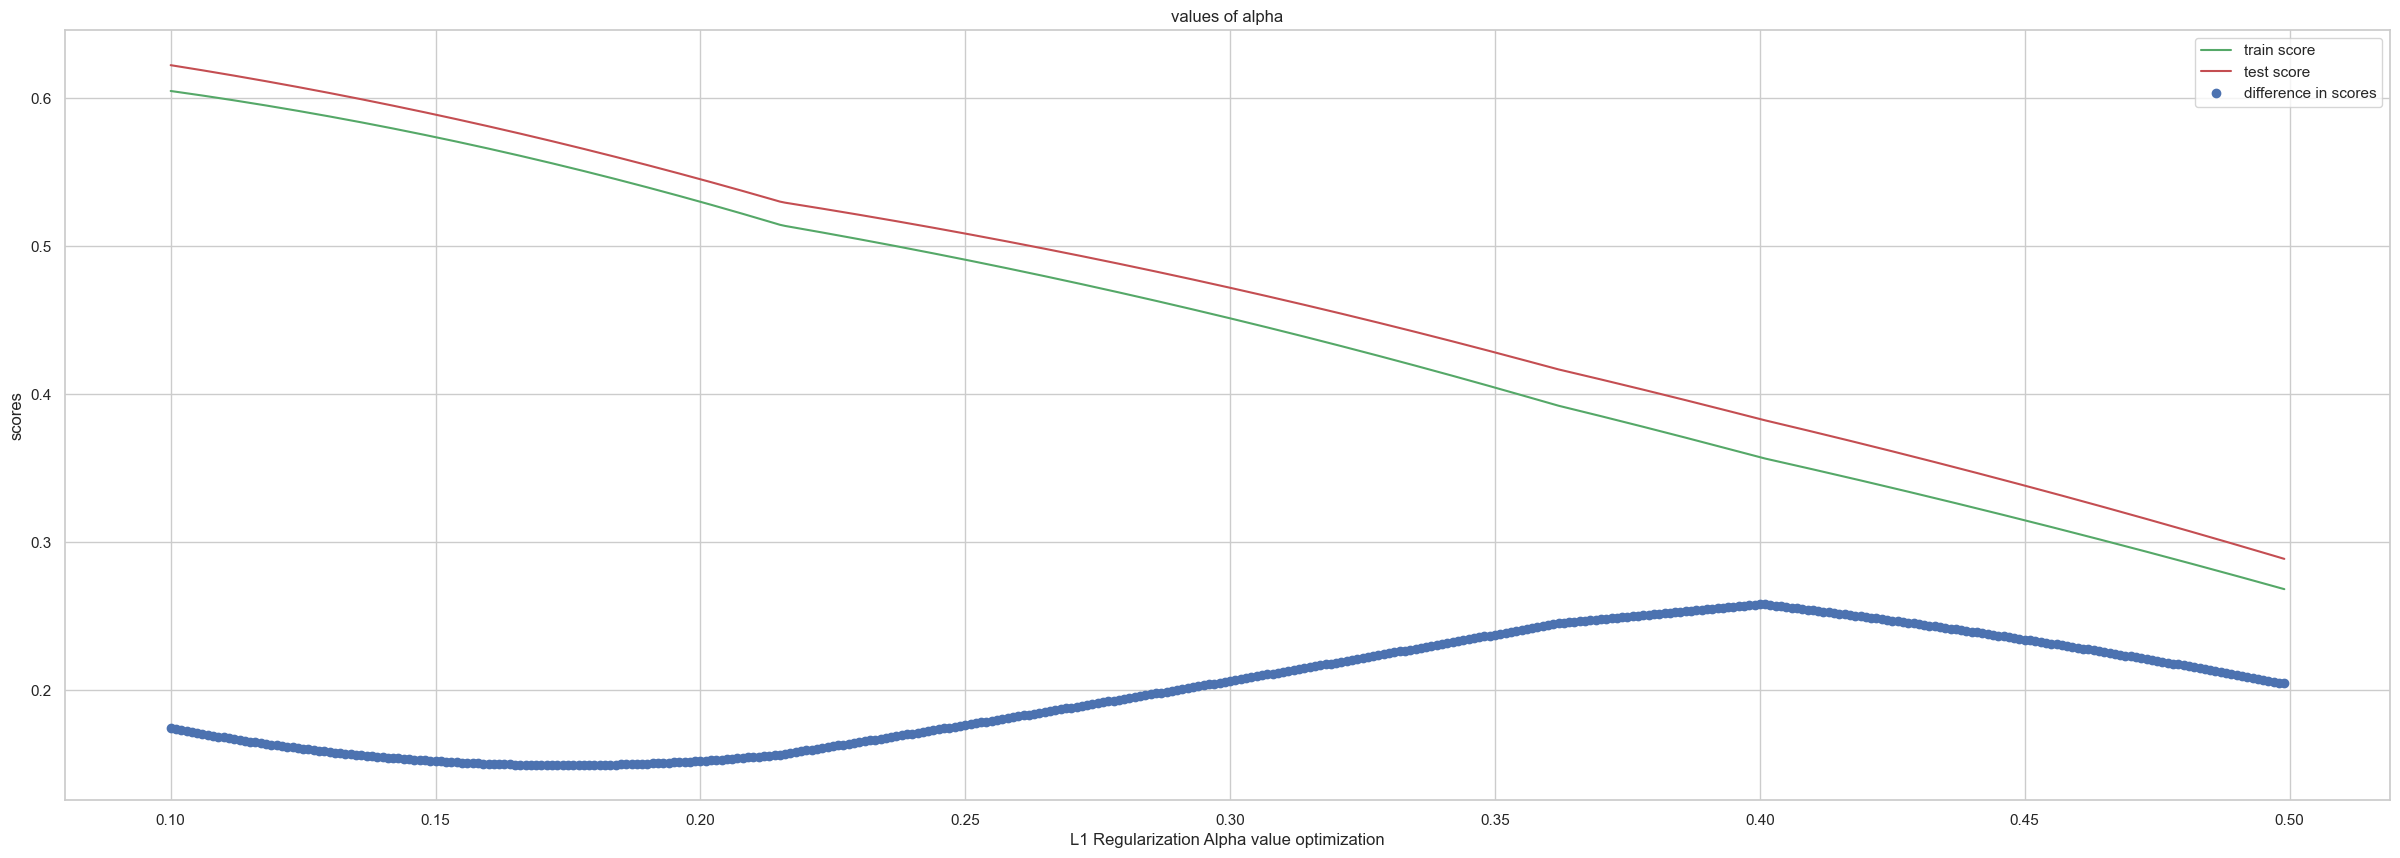

In [45]:
l=np.arange(.1, .5, 0.001)
anumber=[]
trscore=[]
tescore=[]
sdiff=[]
for a in l:

    from sklearn.linear_model import Ridge
    Lasso_reg = linear_model.Lasso(alpha=a)

    Lasso_reg.fit(X_train_scaled,y_train_scaled)
    Lasso_y_pred = Lasso_reg.predict(X_test_scaled) 
    trainscore=Lasso_reg.score(X_train_scaled,y_train_scaled)
    testscore=Lasso_reg.score(X_test_scaled,y_test_scaled)
    diff=(-trainscore+testscore)*10
    anumber.append(a)
    trscore.append(trainscore)
    tescore.append(testscore)
    sdiff.append(diff)
plt.figure(figsize=(30,10))
plt.plot(anumber,trscore,'g',label="train score")
plt.plot(anumber,tescore,'r',label="test score")
plt.plot(anumber,sdiff,'bo',label="difference in scores")
plt.xlabel('L1 Regularization Alpha value optimization') 
plt.ylabel('scores') 
plt.title('values of alpha')
plt.legend() 


at around 0.17 the difference between the test score and train score is at lowest and hence we can choose the optimum value of Alpha as 0.17

In [46]:
from sklearn import linear_model
Lasso_reg = linear_model.Lasso(alpha=.17, max_iter=100, tol=0.1)

Lasso_reg.fit(X_train_scaled,y_train_scaled)
Lasso_y_pred = Lasso_reg.predict(X_test_scaled) 


In [47]:
L1trs=round(Lasso_reg.score(X_train_scaled,y_train_scaled),2)
L1tes=round(Lasso_reg.score(X_test_scaled,y_test_scaled),2)

print(f"with Lasso L1 Regularization the train score is {L1trs}, and the test score is {L1tes} however lets check if all the variables are considered")

with Lasso L1 Regularization the train score is 0.56, and the test score is 0.57 however lets check if all the variables are considered


In [48]:
feature_coefficients_L1 = pd.DataFrame({
    'feature': X.columns,
    'coefficient_L1': np.abs(Lasso_reg.coef_)
}).sort_values(by='coefficient_L1', ascending=False)
feature_coefficients_L1

feature_coefficients = pd.merge(feature_coefficients_LR, feature_coefficients_L1,  on='feature')
feature_coefficients

,feature,coefficient_LR,coefficient_L1
0,X3 distance to the nearest MRT station,0.485131,0.430083
1,X5 latitude,0.225620,0.105623
2,X2 house age,0.220661,0.044923
3,X4 number of convenience stores,0.188937,0.115137
4,X1 transaction date,0.101295,0.000000
5,X6 longitude,0.004938,0.000000


In [49]:
metrics(m="L1 Reression",y_true=y_test_scaled,y_pred=Lasso_y_pred)
metric_Df=pd.DataFrame({'Model':mod,"Mean Absolute Error (MAE)":mae,
"Mean Squared Error (MSE)":mse,
"Root Mean Squared Error (RMSE)":rmse,
"R-squared (R²)":r2,
"Adjusted R-squared":adjusted_r2,
"Mean Absolute Percentage Error (MAPE)":mape,
"Mean Bias Deviation (MBD)":mbd,
"Explained Variance Score":explained_variance})
metric_Df.drop_duplicates().sort_values(by='R-squared (R²)',ascending=False)

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared (R²),Adjusted R-squared,Mean Absolute Percentage Error (MAPE),Mean Bias Deviation (MBD),Explained Variance Score
0,LR,0.438126,0.377787,0.614644,0.671887,0.669219,132.623754,0.048837,0.673958
1,LOOCV,5.687721,61.883015,7.866576,0.639188,0.638312,17.298649,0.012541,0.639188
2,L1 Reression,0.503947,0.489473,0.699624,0.574885,0.571429,137.280946,0.024555,0.575409


Although the socres of L1 Regularization are marginally lower compared to the Linear regression the model has excluded two variables here 

#### L2 Regularization (Ridge)

Lets first find the optimum value of the alpha for the given dataset and plot the same.

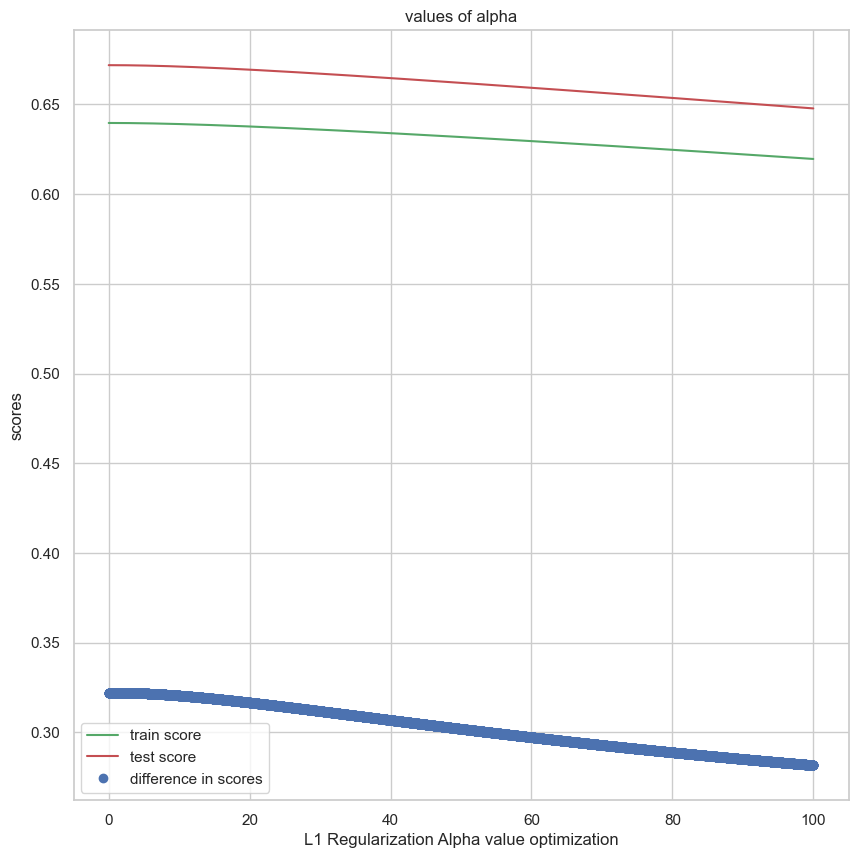

In [50]:
l=np.arange(0, 100, 0.01)
anumber=[]
trscore=[]
tescore=[]
sdiff=[]
for a in l:
    from sklearn.linear_model import Ridge
    ridge_reg = Ridge(alpha=a)

    ridge_reg.fit(X_train_scaled,y_train_scaled)
    Ridge_y_pred = ridge_reg.predict(X_test_scaled) 
    trainscore=ridge_reg.score(X_train_scaled,y_train_scaled)
    testscore=ridge_reg.score(X_test_scaled,y_test_scaled)
    diff=(-trainscore+testscore)*10
    anumber.append(a)
    trscore.append(trainscore)
    tescore.append(testscore)
    sdiff.append(diff)
    # print(a,diff)

plt.figure(figsize=(10,10))
plt.plot(anumber,trscore,'g',label="train score")
plt.plot(anumber,tescore,'r',label="test score")
plt.plot(anumber,sdiff,'bo',label="difference in scores")
plt.xlabel('L1 Regularization Alpha value optimization') 
plt.ylabel('scores') 
plt.title('values of alpha')
plt.legend() 


In [51]:
ridge_reg = Ridge(alpha=.05)

ridge_reg.fit(X_train_scaled,y_train_scaled)
Ridge_y_pred = ridge_reg.predict(X_test_scaled) 

In [52]:
L2trs=round(ridge_reg.score(X_train_scaled,y_train_scaled),2)
L2tes=round(ridge_reg.score(X_test_scaled,y_test_scaled),2)

print(f"with Lasso L2 Regularization the train score is {L2trs}, and the test score is {L2tes} however lets check if all the variables are considered")

with Lasso L2 Regularization the train score is 0.64, and the test score is 0.67 however lets check if all the variables are considered


In [53]:
feature_coefficients_L2 = pd.DataFrame({
    'feature': X.columns,
    'coefficient_L2': np.abs(ridge_reg.coef_)
}).sort_values(by='coefficient_L2', ascending=False)
feature_coefficients_L2
feature_coefficients=pd.merge(feature_coefficients, feature_coefficients_L2,  on='feature')
feature_coefficients

,feature,coefficient_LR,coefficient_L1,coefficient_L2
0,X3 distance to the nearest MRT station,0.485131,0.430083,0.484896
1,X5 latitude,0.225620,0.105623,0.225635
2,X2 house age,0.220661,0.044923,0.220615
3,X4 number of convenience stores,0.188937,0.115137,0.188998
4,X1 transaction date,0.101295,0.000000,0.101268
5,X6 longitude,0.004938,0.000000,0.004797


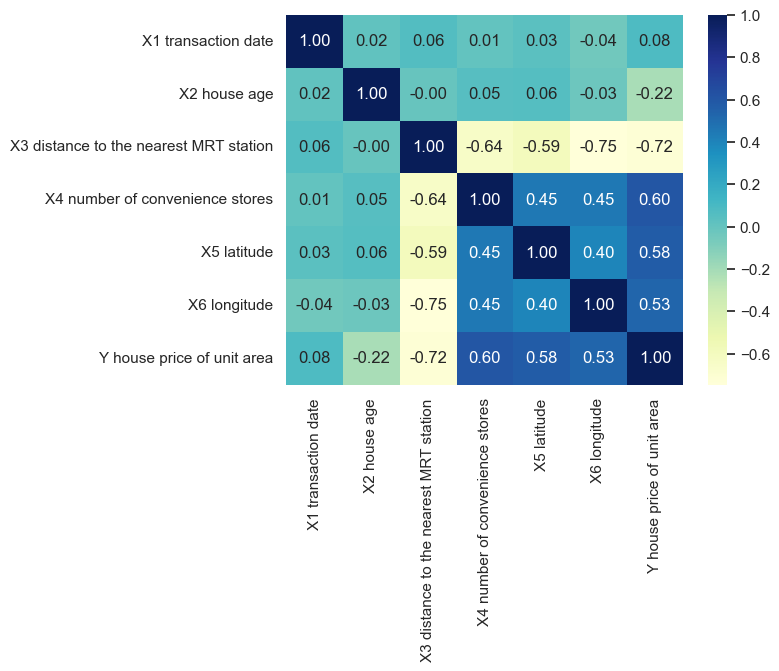

In [54]:
sns.heatmap(df.corr(), annot=True,fmt='.2f',cmap="YlGnBu");
plt.show()

In [55]:
metrics(m="L2 Reression",y_true=y_test_scaled,y_pred=Ridge_y_pred)
metric_Df=pd.DataFrame({'Model':mod,"Mean Absolute Error (MAE)":mae,
"Mean Squared Error (MSE)":mse,
"Root Mean Squared Error (RMSE)":rmse,
"R-squared (R²)":r2,
"Adjusted R-squared":adjusted_r2,
"Mean Absolute Percentage Error (MAPE)":mape,
"Mean Bias Deviation (MBD)":mbd,
"Explained Variance Score":explained_variance})
metric_Df.drop_duplicates().sort_values(by='R-squared (R²)',ascending=False)

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared (R²),Adjusted R-squared,Mean Absolute Percentage Error (MAPE),Mean Bias Deviation (MBD),Explained Variance Score
3,L2 Reression,0.438131,0.377787,0.614644,0.671887,0.669219,132.628381,0.048862,0.673960
0,LR,0.438126,0.377787,0.614644,0.671887,0.669219,132.623754,0.048837,0.673958
1,LOOCV,5.687721,61.883015,7.866576,0.639188,0.638312,17.298649,0.012541,0.639188
2,L1 Reression,0.503947,0.489473,0.699624,0.574885,0.571429,137.280946,0.024555,0.575409


**Observation**

> 1. From the above we can observe that the L1 regression eliminates the coefficients especially X6 Longitude and X1 Transaction Date and supresses the House Age feature's coefficient and still able to bring a better socres between testing and training. <br> 
> 2. Although L2 might have performed well with respect to the magnitude of scores, L1 has given descent score for the dataset with less number of variable. <br>
> 3. The reason behind having high MAE and MSE in LOOCV is because there is an overlap in the training dataset as it is training almost same set of data between two closest training pairs in the index. <br>
> 4. From the corr plot and as well as the coeff it is evident that the highly negative corr leading to the higher coeff. <br>




[10] Stack Exchange, "Why is leave-one-out cross-validation (LOOCV) variance about the mean estimate for test error," Cross Validated, Sep. 19, 2013. [Online]. Available: https://stats.stackexchange.com/questions/90902/why-is-leave-one-out-cross-validation-loocv-variance-about-the-mean-estimate-f. [Accessed: Jul. 28, 2024].


[11] T. Hastie, R. Tibshirani, and J. Friedman, "The Elements of Statistical Learning," 2nd ed. Springer, 2009. [Online]. Available: https://hastie.su.domains/Papers/ESLII.pdf. [Accessed: Jul. 28, 2024].
